# **Katakomba Kaland**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>MI Országos Diákolimpia Válogató</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🧠</span>
    <span>Reinforcement Learning</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>100 + 15 pont</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>2025. Május 24.</span>
  </div>
</div>

**Név:** [ÍRD IDE A NEVED]

**Versenyzői Azonosító:** [ÍRD IDE A VERSENYZŐI AZONOSÍTÓD]

<img src="https://drive.google.com/uc?export=view&id=1fBeRg69OsEpYre_Wk-SAQG6N545PLDjN" alt="kata" style="width:150px;">

Egy bátor **hősnő** kalandozásai során egy régi, elfeledett katakombába zuhan. A kijutás egyetlen módja: **megtalálni az ajtót, amely a felszínre vezet**. A katakomba azonban tele van veszélyekkel - mély szakadékokkal, csapdákkal és kóborló **zombikkal**, akik különböző mintázat szerint járőröznek a sötét folyosókon.

Segíts a hősnőnek kijutni a katakombából **megerősítéses tanulás** (RL) és **mély megerősítéses tanulás** (Deep RL) technikák segítségével. Az algoritmus feladata, hogy megtanulja az optimális útvonalat a bejárattól a kijáratig, elkerülve a veszélyeket, miközben a tanulás során **jutalmazás (reward) segítségével tapasztalatokat gyűjt**.

## **A Környezet (Gymnasium)**

A **Gymnasium** egy megerősítéses tanuláshoz (RL) készült **szabványosított API**, amelyet úgy terveztek, hogy könnyen használható, rugalmas és széleskörűen alkalmazható legyen különféle RL-problémák modellezésére.

A **Gymnasium** célja, hogy egy egyszerű, "*pythonic*" módon használható **interfészt** kínáljon, amely segítségével könnyen lehet modellezni és tesztelni különféle tanulási algoritmusokat. A könyvtár nagy előnye, hogy **egységesíti az RL környezetekkel való kommunikációt**, így a felhasználók könnyedén fókuszálhatnak a tanulási algoritmusok fejlesztésére, **ahelyett hogy minden környezethez külön interfészt kellene írniuk**.

Ehhez a feladathoz egy **egyedi Gymnasium környezetet hoztunk létre**, amely teljes mértékben követi a fentebb ismertetett egységesített API-t. Ennek köszönhetően a katakomba szimuláció könnyen kezelhetővé és **jól integrálhatóvá vált bármilyen megerősítéses tanulási algoritmussal**.

## **Szükséges Importok**

In [ ]:
!pip install -qq creepy-catacombs-s1==0.1.4

from tqdm import tqdm
import numpy as np

import matplotlib.pyplot as plt
import creepy_catacombs_s1
import gymnasium as gym

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.0/17.0 MB 24.7 MB/s eta 0:00:00


### **Környezet Kipróbálása**

Az alábbi két sor segítségével **létrehozzuk a katakomba környezetet**, majd a `reset` függvény segítségével alapállapotba helyezzük azt. A `render_mode='rgb_array'` paraméter biztosítja, hogy a környezet vizuálisan is megjelenjen. A `reset` nemcsak újraindítja a környezetet, **hanem a hősnőt is visszahelyezi a katakomba bejáratához**, az induló pozícióba. A `seed` beállítása azért fontos, mert minden különböző seed más-más katakombastruktúrát generál.

A `reset` két értéket ad vissza: az `obs` (**observation**) tartalmazza az ágens első megfigyelését, például a saját pozícióját, míg az `info` nevű szótár olyan kiegészítő információkat szolgáltat, amelyek hasznosak lehetnek a tanulási folyamat során.

Offline használat esetén a `render_mode='human'` beállítás teljesen működőképes, mivel ez lehetővé teszi a környezet vizualizálását egy külön ablakban a Pygame segítségével. Fontos azonban megjegyezni, hogy ez a megoldás grafikus felületet (X server) igényel, ezért **nem működik Google Colab-on**, ahol nincs natív támogatás az ablakos megjelenítéshez. Colab esetén más renderelési módok, például `rgb_array`, használata javasolt (ebben az alábbi `plot_env` tud segíteni).


In [ ]:
def plot_env(rgb_array: np.ndarray):
    """
    Plots the provided RGB array as an image.

    Args:
        rgb_array (np.ndarray): A NumPy array representing an RGB image.
                                 The array must have shape (height, width, 3),
                                 where the last dimension represents the RGB color channels.
    """
    if not isinstance(rgb_array, np.ndarray):
        raise TypeError("rgb_array must be a NumPy array.")

    if rgb_array.ndim != 3 or rgb_array.shape[2] != 3:
        raise ValueError("rgb_array must have shape (height, width, 3).")

    plt.figure(figsize=(8, 8))
    plt.imshow(rgb_array)
    plt.axis('off')
    plt.show()

In [ ]:
env = gym.make("CreepyCatacombs-v0", render_mode="rgb_array")
obs, info = env.reset(seed=42)
env_rgb = env.render()

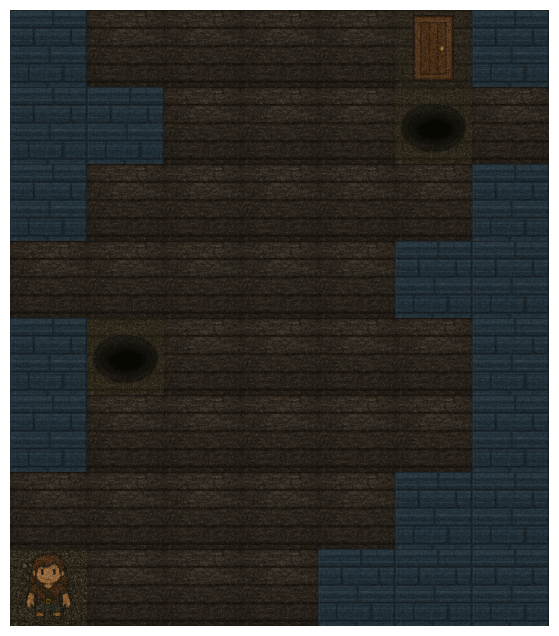

In [ ]:
plot_env(env_rgb)

Ahogy látható, az alapértelmezett környezet **jelenleg nem tartalmaz zombikat** - azonban ez könnyen módosítható. A környezet két további argumentumot is képes kezelni: az `n_zombies` paraméterrel meghatározható, hogy hány zombi jelenjen meg a katakombában, míg a `zombie_movement` paraméter azt szabályozza, hogy ezek a zombik milyen mozgásmintát kövessenek (`random`, `towards_player`).

In [ ]:
env = gym.make("CreepyCatacombs-v0", render_mode="rgb_array", n_zombies = 3, zombie_movement = "random")
obs, info = env.reset(seed=42)
env_rgb = env.render()

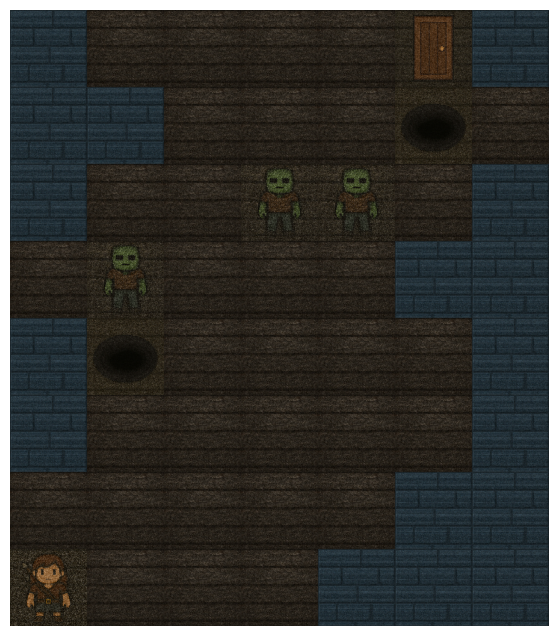

In [ ]:
plot_env(env_rgb)

## **Observation, Info**

Most nézzük meg, hogy pontosan mit tartalmaz az `observation` és az `info`. Ezek azok az adatok, amelyeket minden egyes környezeti interakció során visszakaptok, így kulcsfontosságú szerepük van az ágens tanulásában és döntéshozatalában. Az `observation` az ágens aktuális nézőpontját írja le - például a pozícióját vagy a közvetlen környezetét -, míg az `info` kiegészítő információkat tartalmazhat a pályáról, a cél elhelyezkedéséről vagy más eseményekről, amelyek hasznosak lehetnek az elemzés és vizualizáció során.

In [ ]:
print("Megfigyelési tér:", obs) # Melyik cellában van a hősnő. Az origó a bal felső sarokban található -> 7x7 + 1 - 1 (indexelés miatt) = 49
print("Ágens pozíció: (%d, %d)" % (int(info['agent_pos'][0]), int(info['agent_pos'][1])))
print("Cél pozíció: (%d, %d)" % (int(info['goal_pos'][0]), int(info['goal_pos'][1])))

zombie_positions = [(int(z[0]), int(z[1])) for z in info['zombies']]
print("Zombiak pozíciói:", zombie_positions)
print("Teljes környezet (0 - szabad cella, -1 - fal, -2 - lyuk, 1 - kezdő pozíció, 2 - cél pozíció, 3 - zombi):\n", info['grid'])
print("Környezet mérete: %dx%d" % (int(info["grid_shape"][0]), int(info["grid_shape"][1])))

plothole_positions = [tuple(int(p) for p in plothole) for plothole in info['plotholes']]
print("Lyukak pozíciói", plothole_positions)

Megfigyelési tér: 49
Ágens pozíció: (7, 0)
Cél pozíció: (0, 5)
Zombiak pozíciói: [(2, 4), (3, 1), (2, 3)]
Teljes környezet (0 - szabad cella, -1 - fal, -2 - lyuk, 1 - kezdő pozíció, 2 - cél pozíció, 3 - zombi):
 [[-1  0  0  0  0  2 -1]
 [-1 -1  0  0  0 -2  0]
 [-1  0  0  3  3  0 -1]
 [ 0  3  0  0  0 -1 -1]
 [-1 -2  0  0  0  0 -1]
 [-1  0  0  0  0  0 -1]
 [ 0  0  0  0  0 -1 -1]
 [ 1  0  0  0 -1 -1 -1]]
Környezet mérete: 8x7
Lyukak pozíciói [(1, 5), (4, 1)]


## **Környezet Léptetése**

Ahhoz, hogy a hősnő lépéseket tegyen a katakombában (például fel, le, jobbra vagy balra), a környezet `.step()` függvényét kell meghívnunk. Ez a függvény egy egész számot vár bemenetként, amely a kívánt irányt kódolja. A négy lehetséges lépés az alábbi módon van kódolva:

- `0` - lépés **felfelé**
- `1` - lépés **jobbra**
- `2` - lépés **lefelé**
- `3` - lépés **balra**

Minden egyes `.step()` hívás után a környezet visszaadja az új megfigyelést (`observation`), a kapott jutalmat (`reward`), egy logikai értéket (`done`), amely jelzi, hogy véget ért-e az epizód, valamint az `info` szótárat a kiegészítő adatokkal. **Egy epizód** a megerősítéses tanulásban egy teljes környezetbeli menetet jelent, amely a kezdőállapottól indul, és **addig tart, amíg az ágens eléri a célt vagy egy végállapotot** (pl. beleesik egy lyukba, megtámadja egy zombi). A `truncated` változó azt jelzi, ha az epizód nem természetes módon (pl. célba érkezés), hanem **az engedélyezett maximális lépésszám túllépése miatt szakadt meg**. Ez azt jelenti, hogy az ágens túl sokáig bolyongott a környezetben anélkül, hogy elérte volna a kijáratot vagy hibázott volna, így a rendszer automatikusan lezárta az epizódot.

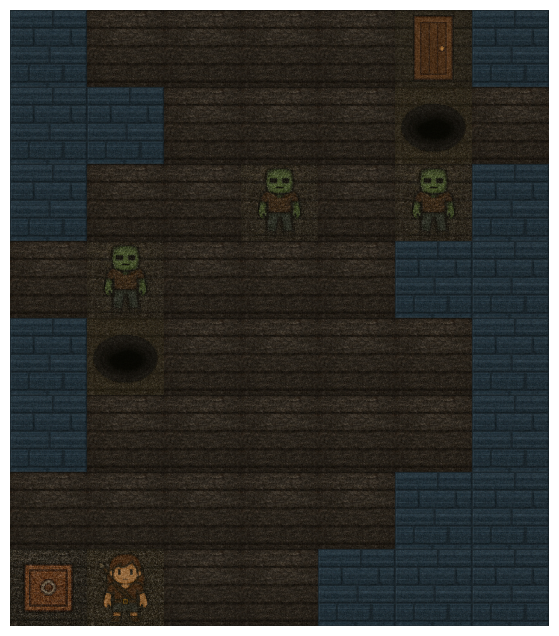

In [ ]:
FEL = 0
JOBBRA = 1
LE = 2
BALRA = 3

obs, reward, done, truncated, info = env.step(1)
env_rgb = env.render()
plot_env(env_rgb)

In [ ]:
print("Kapott jutalom a lépésért: ", reward)
print("Véget ért az epizód? ", done)

Kapott jutalom a lépésért:  -1
Véget ért az epizód?  False


## **Jutalmazási Rendszer**

A katakombák környezetben egy **egyszerű jutalmazási rendszer** segíti az ágens tanulását. A cél az, hogy a hősnő gyorsan, hatékonyan és biztonságosan eljusson a kijárathoz, miközben elkerüli a veszélyeket. Az alábbi táblázat összefoglalja, milyen helyzetekben milyen jutalmat vagy büntetést kap:

| Esemény                                      | Jutalom értéke | Megjegyzés                                 |
|---------------------------------------------|----------------|---------------------------------------------|
| Minden lépés                                | -1             | A gyors kijutást ösztönzi                   |
| Illegális lépés falba                       | -5             | Büntetés falnak ütközésért                  |
| Lyukba esés vagy zombival ütközés           | -100             | Epizód véget ér (`done = True`)             |
| Célba érkezés (kijárat elérése)             | +0           | Epizód véget ér (`done = True`)             |


# **1. Feladat (5 pont)**

Az első feladatotok az, hogy készítsetek **egy előre meghatározott lépéssorozatot** (hardcoded megoldást, **zombik nélkül**), amely sikeresen végigvezeti a hősnőt a katakomba kijáratához a `seed=2025` értékű, determinisztikusan generált pályán.

A megvalósítás során a következőkre figyeljetek:

- A szimuláció végén jelenítsétek meg:
  - a hősnő **végső pozícióját** (amikor a kijáratra lép),
  - az epizód során összegyűjtött **jutalom értékét** (`total_reward`).

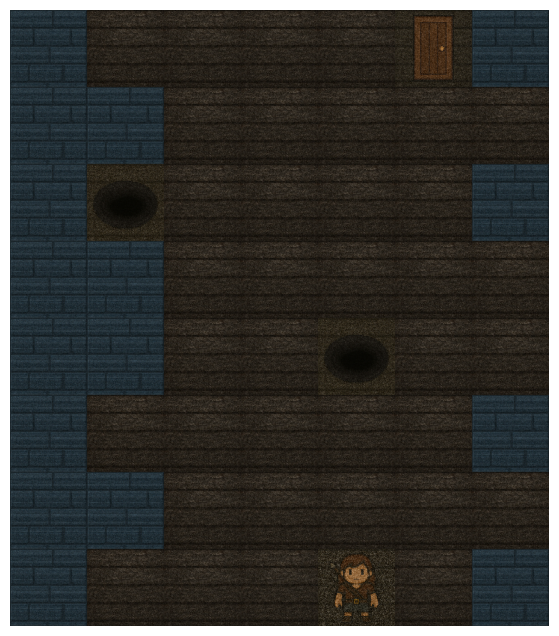

Összjutalom: 0


In [ ]:
env = gym.make("CreepyCatacombs-v0", render_mode="rgb_array")
env.reset(seed=2025)
cum_reward = 0

# --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~5-7 sor)

# ----------- ITT A MEGOLDÁSOD VÉGE -------------

env_rgb = env.render()
plot_env(env_rgb)
print("Összjutalom:", cum_reward)
env.close()

# **2. Feladat (20 pont)**

Készítsetek egy **egyszerű útkereső algoritmust** (pl. backtracking vagy BFS), amely megtalál egy érvényes utat a hősnő számára a startponttól a kijáratig, elkerülve a falakat és akadályokat.

A környezetet `seed=2025` értékkel indítsátok újra. A megtalált út mentén léptessétek végig a hősnőt, és a szimuláció végén írjátok ki:
- a környezet végső állapotát (render)
- az összjutalmat

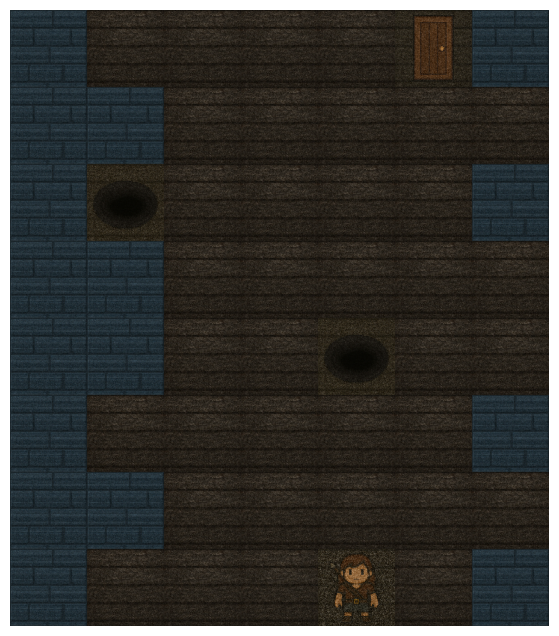

Összjutalom: 0


In [ ]:
env = gym.make("CreepyCatacombs-v0", render_mode="rgb_array")

def search_door(env: gym.Env, seed: int) -> int:
    obs, info = env.reset(seed=seed)
    agent_pos = tuple(info['agent_pos'])
    goal_pos = tuple(info['goal_pos'])
    grid = info['grid']
    total_reward = 0
    # --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~20-30 sor)

    # ----------- ITT A MEGOLDÁSOD VÉGE -------------
    return total_reward

cum_reward = search_door(env, seed=2025)
env_rgb = env.render()
plot_env(env_rgb)
print("Összjutalom:", cum_reward)
env.close()

# **3. Feladat (10 pont)**

Teszteljétek a korábban elkészített heurisztikus megoldást olyan környezetekben, ahol 1, 5, és 9 zombi is jelen van. Minden esetben:

- A `zombie_movement`-et állítsátok véletlenszerűre.
- Állítsátok be a megfelelő `n_zombies` értéket a környezet létrehozásakor.
- Egy adott beállítással **10 epizódot** futtassatok le.
- Minden epizód végén rögzítsétek az elért **összjutalmat**.
- Minden futásnál a környezetet egyedi, de determinisztikus seeddel indítsátok újra: az első epizódnál használjátok a `2025` seedet, majd minden további epizódnál a `2025 + epizód_sorszám` értéket.


Az eredményeket ábrázoljátok egy közös ploton, ahol az x-tengely az epizódok sorszáma, az y-tengely pedig az adott epizódhoz tartozó jutalom. Az ábrán szerepeljen mindhárom eset (1, 5, 9), külön színekkel vagy jelölésekkel megkülönböztetve.

In [ ]:
results = {}

# --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~15 sor)

# ----------- ITT A MEGOLDÁSOD VÉGE -------------

env.close()

# **4. Feladat (15 pont)**

Bővítsétek ki az **előző feladatban készített útkereső algoritmust úgy**, hogy a hősnő ne csak a falakat és lyukakat, **hanem a zombikat is próbálja elkerülni az útvonal megtervezésekor**.

A cél továbbra is az, hogy biztonságosan eljussatok a kijárathoz.

In [ ]:
env = gym.make("CreepyCatacombs-v0", render_mode="rgb_array")

def search_door_avoid_zombies(env: gym.Env, seed: int) -> int:
    obs, info = env.reset(seed=seed)
    agent_pos = tuple(info['agent_pos'])
    goal_pos = tuple(info['goal_pos'])
    grid = info['grid']
    total_reward = 0
    # --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~20-30 sor)

    # ----------- ITT A MEGOLDÁSOD VÉGE -------------
    return total_reward

results = {}

# --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~15 sor)

# ----------- ITT A MEGOLDÁSOD VÉGE -------------
env.close()

# **5. Feladat (20 pont)**

A **Monte Carlo Control** egy modellmentes megerősítéses tanulási algoritmus, amelynek célja az optimális stratégia megtalálása egy olyan környezetben, ahol a környezet dinamikája (azaz, hogy egy adott állapotból egy adott akció hatására milyen lesz a következő állapot és a jutalom) nem ismert. A *Monte Carlo* elnevezés arra utal, hogy az algoritmus véletlenszerű mintavételezésen (epizódokon) alapul a tanuláshoz.

### Alapfogalmak

* **Állapot (State - $s$):** A környezet egy adott pillanatnyi helyzete.
* **Akció (Action - $a$):** Az ágens által a környezetben végrehajtható lépés.
* **Jutalom (Reward - $r$):** A környezet által az ágens egy akciójára adott visszajelzés.
* **Epizód:** Egy teljes sorozat állapotokból, akciókból és jutalmakból, amely egy kezdeti állapottól egy terminális állapotig tart.
* **Hozam (Return - $G$):** Az egy epizód során kapott összes jutalom összege, figyelembe véve a diszkont faktort ($\gamma$). A $t$-edik időpillanattól kezdődő hozam:

    $$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \dots + \gamma^{T-t-1} R_T$$
    ahol $T$ az epizód vége.
* **Q-érték (Action-Value - $Q(s, a)$):** Azon várható hozam, amelyet akkor kapunk, ha az $s$ állapotban az $a$ akciót hajtjuk végre, és ezután az optimális stratégiát követjük. A Monte Carlo Control **közvetlenül a Q-értékeket becsüli.**
* **Stratégia (Policy - $\pi(a|s)$):** Egy szabály, amely megadja, hogy az ágens egy adott állapotban milyen valószínűséggel választ egy adott akciót. A Monte Carlo Control célja az optimális stratégia ($\pi^*$) megtalálása, amely maximalizálja a várható hozamot.
* **Epsilon-mohó stratégia ($\epsilon$-greedy policy):** Egy olyan stratégia, amelyben az ágens a legtöbb időben a jelenlegi becslések szerint legjobb akciót választja (**exploitáció**), de kis valószínűséggel ($\epsilon$) véletlenszerűen is választ akciót (**exploráció**). Ez biztosítja, hogy az ágens ne ragadjon le egy szuboptimális stratégiánál.

### **A Monte Carlo Control Algoritmus Lépései**

A Monte Carlo Control célja **a Q-értékek iteratív javítása az epizódokból származó tapasztalatok alapján, amíg el nem érjük az optimális Q-értékeket**, amelyekből az optimális stratégia levezethető. Az algoritmus tipikus lépései a következők:

1.  **Inicializálás:**
    * Inicializáljuk a Q-érték táblát $Q(s, a)$ minden lehetséges $(s, a)$ párhoz (általában nullára vagy véletlenszerű értékekre).
    * Inicializáljuk egy üres szótárt a hozamok tárolására, például `returns[(s, a)] = []`. Ez a szótár minden (állapot, akció) párhoz tárolja az eddigi epizódokban kapott hozamokat.
    * Megadjuk a diszkont faktort ($\gamma$) és az epsilon ($\epsilon$) kezdeti értékét.

2.  **Epizódok Generálása:**
    * Minden iterációban (epizódban) az ágens a kezdeti állapotból indulva interakcióba lép a környezettel az aktuális stratégiája (például az $\epsilon$-mohó stratégia a jelenlegi Q-értékek alapján) szerint.
    * Az epizód addig tart, amíg el nem érjük egy terminális állapotot.
    * Az epizód során rögzítjük az állapotok, akciók és jutalmak sorozatát: $s_0, a_0, r_1, s_1, a_1, r_2, \dots, s_{T-1}, a_{T-1}, r_T, s_T$.

3.  **Hozamok Kiszámítása:**
    * Az epizód befejezése után kiszámítjuk a hozamot ($G_t$) minden egyes időpillanatra $t=0, 1, \dots, T-1$. A hozam az adott időpillanattól kezdődő összes jövőbeli jutalom diszkontált összege.

4.  **Q-értékek Frissítése:**
    * Minden egyes $(s_t, a_t)$ állapot-akció párra, amely az epizódban előfordult, hozzáadjuk a kiszámított hozamot ($G_t$) a `returns[(s_t, a_t)]` listához.
    * Frissítjük a $Q(s_t, a_t)$ értékét az adott (állapot, akció) párhoz tartozó eddigi hozamok átlagával:
        $$Q(s_t, a_t) \leftarrow \text{mean}(returns[(s_t, a_t)])$$
    * **Első látogatás MC (First-Visit MC) vs. Minden látogatás MC (Every-Visit MC):** A fenti lépés lehet "első látogatás", ami azt jelenti, hogy egy epizódon belül csak az első előfordulásakor frissítjük a Q-értéket egy adott $(s, a)$ párhoz, vagy "minden látogatás", ami azt jelenti, hogy minden egyes alkalommal frissítjük, amikor a pár előfordul az epizódban. A megadott kód a **minden látogatás** megközelítést alkalmazza.

5.  **Stratégia Javítása:**
    * Az epizód végén (vagy bizonyos időközönként) javítjuk a stratégiát a frissített Q-értékek alapján. Például az $\epsilon$-mohó stratégia esetén minden állapotban kiválasztjuk azt az akciót, amelynek a legmagasabb a Q-értéke, kivéve egy kis valószínűséggel ($\epsilon$), amikor véletlenszerűen választunk akciót.
    * Az $\epsilon$ értékét gyakran csökkentik az epizódok előrehaladtával (epsilon decay), hogy az algoritmus egyre inkább a már megtanult legjobb akciókra koncentráljon (exploitáció).

6.  **Ismétlés:**
    * A 2-5. lépéseket ismételjük a megadott számú epizód erejéig vagy amíg a Q-értékek nem konvergálnak.

In [ ]:
# Segítő függvény a plotoláshoz
def moving_average(data, window_size=50):
    if len(data) < window_size:
        return np.convolve(data, np.ones(window_size) / window_size, mode='valid')
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

def monte_carlo_control_estimation(env, episodes=2500, gamma=0.99, epsilon=1.0, epsilon_decay=0.999, min_epsilon=0.01):
    """
    Monte Carlo Control becslési algoritmus implementációja.

    Args:
        env (gym.Env): A környezet, amellyel az ágens interakcióba lép.
        episodes (int): Az epizódok száma, ameddig az algoritmus fut.
        gamma (float): A diszkont faktor (0 és 1 között). Meghatározza a jövőbeli jutalmak jelenlegi értékét.
        epsilon (float): A kezdeti epsilon érték az epsilon-mohó stratégia számára.
        epsilon_decay (float): Az epsilon csökkenési tényező. Minden epizód után az epsilon érték ezzel szorzódik.
        min_epsilon (float): A minimális epsilon érték, ameddig az epsilon csökkenhet.

    Returns:
        tuple: Tartalmazza a simított jutalmakat, az optimális Q-érték táblát és az optimális V-érték táblát.
    """
    # A környezet állapotterének és akciós terének méreteinek lekérdezése
    # 8x7
    n_states = env.observation_space.n
    # 4
    n_actions = env.action_space.n

    # Inicializáljuk a Q-érték táblát (állapot-akció értékek). Minden érték kezdetben 0.
    Q = np.zeros((n_states, n_actions))
    # Inicializáljuk a 'returns' szótárt, amely tárolja az egyes (állapot, akció) párokhoz tartozó eddigi hozamokat.
    returns = {}
    # Inicializáljuk a kumulatív jutalmak listáját, amely az egyes epizódokban elért teljes jutalmat tárolja.
    cum_rewards = []

    # Végigmegyünk a megadott számú epizódon
    for ep in tqdm(range(episodes)):
        # Az epizód elején visszaállítjuk a környezetet a kezdeti állapotba.
        state, info = env.reset(seed = 2025)
        # Az aktuális epizód lépéseinek tárolására szolgáló lista. Minden lépés egy (állapot, akció, jutalom) hármas.
        episode = []
        # Jelzi, hogy az epizód befejeződött-e (elértük a terminális állapotot).
        done = False
        # Jelzi, hogy az epizód valamilyen okból megszakadt-e (pl. időkorlát).
        truncated = False
        # Az aktuális epizód teljes jutalmának nyomon követésére szolgáló változó.
        total_reward = 0

        # --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~15-20 sor)

        # ----------- ITT A MEGOLDÁSOD VÉGE -------------

        # Az epsilon értékének csökkentése a felfedezés mértékének csökkentése érdekében az epizódok előrehaladtával.
        epsilon = max(min_epsilon, epsilon * epsilon_decay)

    # Az optimális V-érték tábla (állapotértékek) a Q-érték tábla sorainak maximumával egyenlő.
    V = np.max(Q, axis=1)
    # Meghatározzuk a mozgóátlag ablakméretét a jutalmak simításához a plotoláshoz.
    plot_window_size = min(50, episodes // 5 if episodes >= 5 else 1)
    # Kiszámítjuk a simított jutalmakat a mozgóátlag segítségével.
    smoothed_rewards = moving_average(cum_rewards, window_size=50)
    # Létrehozunk egy x-tengelyt a simított jutalmak plotolásához.
    smoothed_x = np.arange(plot_window_size - 1, len(cum_rewards))

    # A jutalmak alakulásának plotolása az epizódok során.
    plt.figure(figsize=(12, 6))
    plt.plot(smoothed_x, smoothed_rewards, label=f"Átlagolt Jutalmak (Ablakméret={plot_window_size})", color='blue')
    plt.xlabel("Epizód")
    plt.ylabel("Összjutalom")
    plt.title("Monte Carlo Control: Összjutalom Epizódonként")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Visszaadjuk a simított jutalmakat, az optimális Q-érték táblát és az optimális V-érték táblát.
    return smoothed_rewards, Q, V

In [ ]:
env = gym.make("CreepyCatacombs-v0", render_mode="rgb_array")
smoothed_rewards_MC, Q_table_MC, V_table_MC = monte_carlo_control_estimation(env,
                                                  episodes=2500,
                                                  gamma=0.99,
                                                  epsilon=1.0,
                                                  epsilon_decay=0.999,
                                                  min_epsilon=0.01)

# **6. Feladat (5 pont)**

Az `env` környezet biztosít számotokra három vizualizációs függvényt, amelyek segítségével megjeleníthetitek az algoritmus által tanult értékeket és stratégiákat. Ezek a függvények RGB képként (tömbként) térnek vissza, amelyeket a korábban definiált `plot_env()` függvénnyel könnyedén meg tudtok jeleníteni.

**A három elérhető vizualizáció:**

- `env.unwrapped.render_values(V)`  
  Az állapotokhoz tartozó értékeket (`state: value`) várja szótár formájában.  
  Ez a függvény az értékfüggvény \(V(s)\) vizualizációját adja vissza.

- `env.unwrapped.render_q_values(Q)`  
  Állapot-akció párokat vár szótárként (`(state, action): Q-value`), és a Q-értékeket jeleníti meg.  
  Ez a \(Q(s, a)\) értékfüggvény vizualizációjához használható.

- `env.unwrapped.render_optimal_path(policy)`  
  A legjobb akciókat tartalmazó policy-t (`np.argmax(Q_table, axis=1)`) várja, és megjeleníti az optimális utat a stratégiában.

Minden függvény RGB képként tér vissza, így egyszerűen kirajzolható a `plot_env` függvény segítségével.

In [ ]:
state, info = env.reset(seed=2025)

# --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~10 sor)

# ----------- ITT A MEGOLDÁSOD VÉGE -------------

env.close()

# **7. Feladat (20 pont)**

A **SARSA** (State-Action-Reward-State-Action) egy on-policy temporális differencia (**Temporal Difference - TD**) tanulási algoritmus, amelyet a megerősítéses tanulásban használnak az optimális stratégia megtalálására. Az *on-policy* jelző csak azt jelenti, hogy az algoritmus azzal a stratégiával tanul, amelyet éppen használ az akciók kiválasztásához.

### Alapfogalmak

* **Állapot (State - $s$):** A környezet egy adott pillanatnyi helyzete.
* **Akció (Action - $a$):** Az ügynök által a környezetben végrehajtható lépés.
* **Jutalom (Reward - $r$):** A környezet által az ügynök egy akciójára adott visszajelzés.
* **Q-érték (Action-Value - $Q(s, a)$):** Azon várható hozam, amelyet akkor kapunk, ha az $s$ állapotban az $a$ akciót hajtjuk végre, és ezután a jelenlegi stratégiát követjük. A SARSA közvetlenül a Q-értékeket becsüli.
* **Stratégia (Policy - $\pi(a|s)$):** Egy szabály, amely megadja, hogy az ügynök egy adott állapotban milyen valószínűséggel választ egy adott akciót. **A SARSA egy adott stratégia Q-értékeit tanulja.**
* **Tanulási ráta (Learning Rate - $\alpha$):** Egy paraméter, amely meghatározza, hogy az új tapasztalatok mennyire befolyásolják a korábbi Q-értékeket. Egy magasabb tanulási ráta azt jelenti, hogy az új tapasztalatok nagyobb súllyal esnek latba.
* **Diszkont faktor (Discount Factor - $\gamma$):** Egy paraméter (0 és 1 között), amely meghatározza a jövőbeli jutalmak jelenlegi értékét. Egy alacsonyabb diszkont faktor a közvetlen jutalmakat részesíti előnyben, míg egy magasabb érték a hosszú távú jutalmakat is figyelembe veszi.
* **Epsilon-mohó stratégia ($\epsilon$-greedy policy):** Egy stratégia, amelyben az ügynök a legtöbb időben a jelenlegi becslések szerint legjobb akciót választja (**exploitáció**), de kis valószínűséggel ($\epsilon$) véletlenszerűen is választ akciót (**exploráció**).

### **A SARSA Algoritmus Lépései**

A SARSA algoritmus egy epizód során lépésről lépésre frissíti a Q-értékeket a következőképpen:

1.  **Inicializálás:**
    * Inicializáljuk a Q-érték táblát $Q(s, a)$ minden lehetséges $(s, a)$ párhoz (általában nullára vagy véletlenszerű értékekre).
    * Megadjuk a tanulási rátát ($\alpha$), a diszkont faktort ($\gamma$) és az epsilon ($\epsilon$) kezdeti értékét.

2.  **Epizódok Végrehajtása:**
    * Minden epizódban a kezdeti állapotból ($s_t$) indulunk.
    * Az aktuális stratégia (pl. $\epsilon$-mohó a jelenlegi Q-értékek alapján) segítségével kiválasztunk egy akciót ($a_t$) az $s_t$ állapotban.
    * Végrehajtjuk az $a_t$ akciót, és megfigyeljük a következő állapotot ($s_{t+1}$) és a kapott jutalmat ($r_{t+1}$).
    * A következő állapotban ($s_{t+1}$) ismét kiválasztunk egy akciót ($a_{t+1}$) ugyanazon stratégia alapján.
    * Frissítjük a Q-értéket az éppen megtapasztalt átmenet alapján a következő képlettel:
        $$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha [r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t)]$$
    * Az aktuális állapot és akció lesz a következő lépés állapota és akciója ($s_t \leftarrow s_{t+1}$, $a_t \leftarrow a_{t+1}$).
    * Ezt a folyamatot addig ismételjük, amíg el nem érjük egy terminális állapotot.

3.  **Epsilon Csökkentése:**
    * Az epizódok előrehaladtával csökkenthetjük az epsilon értékét (epsilon decay), hogy az ügynök egyre inkább a már megtanult legjobb akciókra koncentráljon (exploitáció) ahelyett, hogy véletlenszerűen cselekedne (exploráció).

4.  **Ismétlés:**
    * A 2. és 3. lépéseket ismételjük a megadott számú epizód erejéig vagy **amíg a Q-értékek nem konvergálnak.**

In [ ]:
# Segitő függvény a SARSA algoritmushoz
def epsilon_greedy_policy(Q, state, epsilon, n_actions):
    """
    Implementálja az epsilon-mohó stratégiát az akció kiválasztásához.

    Args:
        Q (numpy.ndarray): A Q-érték tábla (állapot-akció értékek).
        state (int): Az aktuális állapot.
        epsilon (float): A valószínűség, hogy véletlenszerű akciót választunk (exploráció).
        n_actions (int): Az elérhető akciók száma.

    Returns:
        int: A kiválasztott akció indexe.
    """
    if np.random.rand() < epsilon:
        # Ha egy véletlen szám kisebb, mint az epsilon, akkor véletlenszerűen választunk egy akciót (exploráció).
        return np.random.choice(n_actions)
    else:
        # Egyébként a jelenlegi állapotban a legmagasabb Q-értékkel rendelkező akciót választjuk (exploitáció).
        q_values = Q[state, :]
        max_q = np.max(q_values)
        best_actions = np.where(q_values == max_q)[0]
        # Ha több legjobb akció is van, véletlenszerűen választunk közülük egyet.
        return np.random.choice(best_actions)

def sarsa_modified(env, episodes=1000, alpha=0.1, gamma=0.99,
                    epsilon=1.0, epsilon_decay=0.999, min_epsilon=0.01):
    """
    A SARSA (State-Action-Reward-State-Action) algoritmus implementációja.

    Args:
        env (gym.Env): A környezet, amellyel az ágens interakcióba lép.
        episodes (int): Az epizódok száma, ameddig az algoritmus fut.
        alpha (float): A tanulási ráta (0 és 1 között). Meghatározza, hogy mennyire frissítjük a Q-értékeket az új tapasztalatok alapján.
        gamma (float): A diszkont faktor (0 és 1 között). Meghatározza a jövőbeli jutalmak jelenlegi értékét.
        epsilon (float): A kezdeti epsilon érték az epsilon-mohó stratégia számára.
        epsilon_decay (float): Az epsilon csökkenési tényező. Minden epizód után az epsilon érték ezzel szorzódik.
        min_epsilon (float): A minimális epsilon érték, ameddig az epsilon csökkenhet.

    Returns:
        tuple: Tartalmazza a simított jutalmakat, az optimális Q-érték táblát és az optimális V-érték táblát.
    """
    # A környezet állapotterének és akciós terének méreteinek lekérdezése
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    # Inicializáljuk a Q-érték táblát (állapot-akció értékek). Minden érték kezdetben 0.
    Q = np.zeros((n_states, n_actions))

    # Inicializáljuk a kumulatív jutalmak listáját, amely az egyes epizódokban elért teljes jutalmat tárolja.
    cum_rewards = []
    # Beállítjuk az aktuális epsilon értékét a kezdeti értékre.
    current_epsilon = epsilon

    # Végigmegyünk a megadott számú epizódon
    for ep in tqdm(range(episodes)):
        # Az epizód elején visszaállítjuk a környezetet a kezdeti állapotba.
        state, info = env.reset(seed = 2025)
        # Az aktuális epizód teljes jutalmának nyomon követésére szolgáló változó.
        total_reward = 0
        # Kiválasztunk egy akciót az epsilon-mohó stratégia alapján a kezdeti állapotban.
        action = epsilon_greedy_policy(Q, state, current_epsilon, n_actions)
        # Jelzi, hogy az epizód befejeződött-e (elértük a terminális állapotot).
        done = False
        # Jelzi, hogy az epizód valamilyen okból megszakadt-e (pl. időkorlát).
        truncated = False
        # --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~10 sor)

        # ----------- ITT A MEGOLDÁSOD VÉGE -------------
        cum_rewards.append(total_reward)

        # Az epsilon értékének csökkentése a felfedezés mértékének csökkentése érdekében az epizódok előrehaladtával.
        current_epsilon = max(min_epsilon, current_epsilon * epsilon_decay)

    # Az optimális V-érték tábla (állapotértékek) a Q-érték tábla sorainak maximumával egyenlő.
    V = np.max(Q, axis=1)

    # Meghatározzuk a mozgóátlag ablakméretét a jutalmak simításához a plotoláshoz.
    plot_window_size = min(100, episodes // 5 if episodes >= 5 else 1)
    # Kiszámítjuk a simított jutalmakat a mozgóátlag segítségével.
    smoothed_rewards = moving_average(cum_rewards, window_size=plot_window_size)
    # Létrehozunk egy x-tengelyt a simított jutalmak plotolásához.
    smoothed_x = np.arange(plot_window_size - 1, len(cum_rewards))

    # A jutalmak alakulásának plotolása az epizódok során.
    plt.figure(figsize=(12, 6))
    plt.plot(smoothed_x, smoothed_rewards, label=f"Átlagolt Jutalmak (Ablakméret={plot_window_size})", color='red')
    plt.xlabel("Epizód")
    plt.ylabel("Összjutalom")
    plt.title(f"SARSA: Összjutalom Epizódonként (α={alpha}, γ={gamma})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Visszaadjuk a simított jutalmakat, az optimális Q-érték táblát és az optimális V-érték táblát.
    return smoothed_rewards, Q, V

In [ ]:
env = gym.make("CreepyCatacombs-v0", render_mode="rgb_array")
smoothed_rewards_sarsa, Q_table_sarsa, V_table_sarsa = sarsa_modified(env,
                                              episodes=2500,
                                              alpha=0.1,
                                              gamma=0.99,
                                              epsilon=1.0,
                                              epsilon_decay=0.999,
                                              min_epsilon=0.01)

# **8. Feladat (5 pont)**

Ismételd meg a **6. feladatban** végrehajtott módosításokat, ezúttal a **SARSA algoritmusra** alkalmazva!


In [ ]:
state, info = env.reset(seed=2025)
# --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~10 sor)

# ----------- ITT A MEGOLDÁSOD VÉGE -------------
env.close()

# **9. Feladat (+15 pont, extra)**

Készíts egy közös plotot, amelyen összehasonlítod a **mozgóátlaggal elsimított jutalmakat** a Monte Carlo (MC) és a SARSA algoritmusok esetén. Használj azonos környezetet és tanulási paramétereket a két módszernél.

Ezután futtasd le az MC algoritmust olyan környezetben, ahol **2 zombi** található, **véletlenszerű mozgásmintával** (`zombie_movement="random"`), és vizsgáld meg, hogyan változik a tanulás az eredeti környezethez képest.

A vizsgálat során vedd figyelembe a **6. és 8. feladatban** elvárt módosításokat, és írd le megfigyeléseidet az eltérésekről.

In [ ]:
# --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~8 sor)
# Plot
# ----------- ITT A MEGOLDÁSOD VÉGE -------------

env = gym.make("CreepyCatacombs-v0", render_mode="rgb_array", n_zombies = 2, zombie_movement = "random")
smoothed_rewards_MC_zombie, Q_table_MC_zombie, V_table_MC_zombie = monte_carlo_control_estimation(env,
                                                  episodes=2500,
                                                  gamma=0.99,
                                                  epsilon=1.0,
                                                  epsilon_decay=0.999,
                                                  min_epsilon=0.01)
state, info = env.reset(seed=2025)
# --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~10 sor)

# ----------- ITT A MEGOLDÁSOD VÉGE -------------
env.close()

---

## 🎉 Gratulálunk!

A feladatsor végére értél - kiváló munkát végeztél!  

---